# Homework 5 Problem 2: Swin Fine-Tuning vs. Scratch

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook is the executed Python notebook for Problem 2. It shows the Swin fine-tuning implementation in small blocks, then displays the completed metrics, histories, and plots. The main comparison is between head-only fine-tuning from pretrained Swin backbones and training a Swin model from random initialization.


## Experiment Setup

Problem 2 fine-tunes Hugging Face Swin-Tiny and Swin-Small on CIFAR-100 by replacing the classifier head and freezing the pretrained backbone. Both pretrained models train only the 100-class head for 5 epochs with batch size 32 and learning rate 2e-5.

The scratch comparison uses a Swin-Tiny-sized model initialized without pretrained weights and trains all parameters for 5 epochs with learning rate 0.001. All three runs use 224 by 224 resized CIFAR-100 images so the preprocessing is consistent across the Swin comparisons.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Code, Image, Markdown, display

ROOT = Path.cwd()
__file__ = str(ROOT / 'src' / 'hw5_swin.py')
RESULTS = ROOT / 'Results_Problem_2'
history_path = RESULTS / 'problem2_history.csv'
summary_path = RESULTS / 'problem2_summary.csv'
plot_path = RESULTS / 'problem2_training_curves.png'
detail_path = RESULTS / 'problem2_epoch_detail.png'
metric_grid_path = RESULTS / 'problem2_metric_grid.png'
trend_path = RESULTS / 'problem2_interpolated_trends.png'
tradeoff_path = RESULTS / 'problem2_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Detail plot:', detail_path)
print('Metric grid:', metric_grid_path)
print('Reference-style trend plot:', trend_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_2/problem2_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_2/problem2_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_training_curves.png
Detail plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_epoch_detail.png
Metric grid: /home/gilberto/Homework_5/Results_Problem_2/problem2_metric_grid.png
Reference-style trend plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_interpolated_trends.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_tradeoffs.png


## Source Walkthrough

I split the Swin implementation into the order needed to understand the experiment. The cells below are normal Python cells, not display wrappers. They define the fine-tuning and scratch-training pipeline without starting the long GPU runs again. The final script launcher is disabled only in this notebook copy; the original `src/` script still runs from the command line.


### Step 1: Imports, Constants, and Dependency Check

This first cell imports the PyTorch, torchvision, pandas, and Hugging Face pieces used in the Swin experiments. It also sets paths, seed, device selection, and the optional Transformers dependency check.


In [2]:
from __future__ import annotations

import argparse
import csv
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

try:
    from transformers import AutoImageProcessor, SwinForImageClassification
except ModuleNotFoundError:
    AutoImageProcessor = None
    SwinForImageClassification = None


torch.set_num_threads(2)
SEED = 4106
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "Results_Problem_2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 100



print('Loaded imports, paths, device selection, and dependency checks.')


Loaded imports, paths, device selection, and dependency checks.


### Step 2: Experiment Records

These dataclasses keep each Swin run and result row organized. They explicitly track pretrained status, frozen-backbone status, total parameters, trainable parameters, runtime, loss, and accuracy.


In [3]:
@dataclass
class SwinConfig:
    model_name: str
    pretrained: bool
    frozen_backbone: bool
    huggingface_id: str | None
    batch_size: int
    epochs: int
    learning_rate: float
    image_size: int


@dataclass
class SwinResult:
    model_name: str
    pretrained: bool
    frozen_backbone: bool
    total_parameter_count: int | None
    parameter_count: int | None
    train_time_per_epoch_sec: float | None
    final_train_loss: float | None
    final_val_loss: float | None
    test_accuracy_pct: float | None
    notes: str = ""



print('Defined structured records for Swin configurations and results.')


Defined structured records for Swin configurations and results.


### Step 3: Reproducibility and Parameter Counts

This section handles seeding and parameter counting. The total-versus-trainable distinction is important because the pretrained models freeze the backbone and train only the classifier head.


In [4]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dirs() -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def count_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def count_all_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())



print('Loaded seeding helpers and total/trainable parameter counters.')


Loaded seeding helpers and total/trainable parameter counters.


### Step 4: CIFAR-100 Data and Evaluation

This is the shared CIFAR-100 data pipeline for all Swin runs. All models use 224 by 224 resized images so pretrained and scratch results are compared under the same input preprocessing.


In [5]:
def get_loaders(batch_size: int, image_size: int = 224, num_workers: int = 0) -> tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, test_loader


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, use_hf: bool) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(pixel_values=inputs).logits if use_hf else model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
    return {
        "loss": total_loss / max(1, total_samples),
        "accuracy_pct": 100.0 * total_correct / max(1, total_samples),
    }



print('Defined CIFAR-100 loaders and the evaluation pass.')


Defined CIFAR-100 loaders and the evaluation pass.


### Step 5: Training Loop

This loop supports both Hugging Face Swin outputs and torchvision Swin outputs. It records epoch-level loss, accuracy, and runtime for the history curves.


In [6]:
def train_model(model: nn.Module, config: SwinConfig, train_loader: DataLoader, test_loader: DataLoader, use_hf: bool) -> tuple[list[dict[str, float]], SwinResult]:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.learning_rate)
    criterion = nn.CrossEntropyLoss()
    history: list[dict[str, float]] = []
    start_all = time.perf_counter()
    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        start_epoch = time.perf_counter()
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(pixel_values=inputs).logits if use_hf else model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
        val_metrics = evaluate_model(model, test_loader, criterion, use_hf)
        history.append({
            "model_name": config.model_name,
            "epoch": epoch,
            "train_loss": total_loss / max(1, total_samples),
            "val_loss": val_metrics["loss"],
            "train_accuracy_pct": 100.0 * total_correct / max(1, total_samples),
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "epoch_seconds": time.perf_counter() - start_epoch,
        })
        latest = history[-1]
        print(
            f"{config.model_name} epoch {epoch}/{config.epochs}: "
            f"train_loss={latest['train_loss']:.4f}, "
            f"val_loss={latest['val_loss']:.4f}, "
            f"val_acc={latest['val_accuracy_pct']:.2f}%, "
            f"seconds={latest['epoch_seconds']:.1f}",
            flush=True,
        )

    average_epoch_seconds = (time.perf_counter() - start_all) / max(1, config.epochs)
    final = history[-1]
    result = SwinResult(
        model_name=config.model_name,
        pretrained=config.pretrained,
        frozen_backbone=config.frozen_backbone,
        total_parameter_count=count_all_parameters(model),
        parameter_count=count_parameters(model),
        train_time_per_epoch_sec=average_epoch_seconds,
        final_train_loss=final["train_loss"],
        final_val_loss=final["val_loss"],
        test_accuracy_pct=final["val_accuracy_pct"],
        notes=f"device={DEVICE.type}",
    )
    return history, result



print('Defined the shared Swin training loop and history collection.')


Defined the shared Swin training loop and history collection.


### Step 6: CSV Reporting

This section writes the history and summary CSV files. Those saved artifacts are what the notebook and PDF use for tables and plots.


In [7]:
def append_history(rows: list[dict[str, float]], replace_model: str | None = None) -> None:
    history_path = RESULTS_DIR / "problem2_history.csv"
    existing: list[dict[str, object]] = []
    if replace_model is not None and history_path.exists() and history_path.stat().st_size > 0:
        current = pd.read_csv(history_path)
        if "model_name" in current.columns:
            current = current[current["model_name"] != replace_model]
        existing = current.to_dict(orient="records")

    exists = history_path.exists()
    mode = "w" if replace_model is not None else "a"
    with history_path.open(mode, newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        if mode == "w" or not exists or history_path.stat().st_size == 0:
            writer.writeheader()
        for row in existing:
            writer.writerow(row)
        for row in rows:
            writer.writerow(row)


def write_summary(rows: list[SwinResult]) -> None:
    summary_path = RESULTS_DIR / "problem2_summary.csv"
    with summary_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(asdict(rows[0]).keys()))
        writer.writeheader()
        for row in rows:
            writer.writerow(asdict(row))



print('Defined CSV output helpers for the saved artifacts.')


Defined CSV output helpers for the saved artifacts.


### Step 7: Swin Model Builders

This is where the pretrained Swin-Tiny and Swin-Small models are loaded, their classifier heads are replaced, the backbones are frozen, and the scratch Swin baseline is created.


In [8]:
def default_configs() -> list[SwinConfig]:
    return [
        SwinConfig("swin_tiny_pretrained", True, True, "microsoft/swin-tiny-patch4-window7-224", 32, 5, 2e-5, 224),
        SwinConfig("swin_small_pretrained", True, True, "microsoft/swin-small-patch4-window7-224", 32, 5, 2e-5, 224),
        SwinConfig("swin_scratch", False, False, None, 32, 5, 1e-3, 224),
    ]


def require_transformers() -> None:
    if AutoImageProcessor is None or SwinForImageClassification is None:
        raise RuntimeError(
            "The 'transformers' package is not installed. Install it before running pretrained Swin experiments."
        )


def build_pretrained_model(config: SwinConfig) -> nn.Module:
    require_transformers()
    model = SwinForImageClassification.from_pretrained(
        config.huggingface_id,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,
    )
    if config.frozen_backbone:
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
    return model


def build_scratch_model() -> nn.Module:
    model = models.swin_t(weights=None)
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
    elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    return model



print('Defined pretrained, frozen-backbone, and scratch Swin builders.')


Defined pretrained, frozen-backbone, and scratch Swin builders.


### Step 8: Experiment Runners

These helper functions connect command-line choices to the actual pretrained or scratch runs. They avoid manual edits when switching between Swin-Tiny, Swin-Small, and scratch Swin.


In [9]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Homework 5 Problem 2: Swin models")
    parser.add_argument("--run-pretrained", type=str, default=None, help="swin_tiny_pretrained or swin_small_pretrained")
    parser.add_argument("--run-scratch", action="store_true")
    parser.add_argument("--epochs", type=int, default=None)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--image-size", type=int, default=None)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--num-threads", type=int, default=None)
    parser.add_argument("--reset-history", action="store_true")
    return parser.parse_args()


def maybe_reset_history() -> None:
    history_path = RESULTS_DIR / "problem2_history.csv"
    if history_path.exists():
        history_path.unlink()


def override_config(config: SwinConfig, args: argparse.Namespace) -> SwinConfig:
    return SwinConfig(
        model_name=config.model_name,
        pretrained=config.pretrained,
        frozen_backbone=config.frozen_backbone,
        huggingface_id=config.huggingface_id,
        batch_size=args.batch_size or config.batch_size,
        epochs=args.epochs or config.epochs,
        learning_rate=config.learning_rate,
        image_size=args.image_size or config.image_size,
    )


def refresh_summary(results: list[SwinResult]) -> None:
    summary_path = RESULTS_DIR / "problem2_summary.csv"
    if summary_path.exists():
        existing = pd.read_csv(summary_path)
        by_name = {row.model_name: asdict(row) for row in results}
        merged = []
        for record in existing.to_dict(orient="records"):
            merged.append(by_name.get(record["model_name"], record))
        for row in merged:
            row.setdefault("total_parameter_count", None)
        write_summary([SwinResult(**row) for row in merged])
        return
    write_summary(results)


def run_pretrained(config_name: str, args: argparse.Namespace) -> SwinResult:
    config_map = {config.model_name: config for config in default_configs() if config.pretrained}
    if config_name not in config_map:
        raise ValueError(f"Unknown pretrained config: {config_name}")
    config = override_config(config_map[config_name], args)
    train_loader, test_loader = get_loaders(config.batch_size, image_size=config.image_size, num_workers=args.num_workers)
    history, result = train_model(build_pretrained_model(config), config, train_loader, test_loader, use_hf=True)
    result.notes = f"{result.notes},image_size={config.image_size},batch_size={config.batch_size}"
    append_history(history, replace_model=config.model_name)
    return result


def run_scratch(args: argparse.Namespace) -> SwinResult:
    config = override_config(next(config for config in default_configs() if config.model_name == "swin_scratch"), args)
    train_loader, test_loader = get_loaders(config.batch_size, image_size=config.image_size, num_workers=args.num_workers)
    history, result = train_model(build_scratch_model(), config, train_loader, test_loader, use_hf=False)
    result.notes = f"{result.notes},image_size={config.image_size},batch_size={config.batch_size}"
    append_history(history, replace_model=config.model_name)
    return result



print('Defined command-line helpers and experiment runners.')


Defined command-line helpers and experiment runners.


### Step 9: Script Entry Point

This final section wires the command-line arguments to the runner functions used to reproduce the completed experiments.


In [10]:
def main() -> None:
    args = parse_args()
    if args.num_threads is not None:
        torch.set_num_threads(args.num_threads)
    else:
        torch.set_num_threads(min(8, os.cpu_count() or 2))
    set_seed()
    ensure_dirs()
    if args.reset_history:
        maybe_reset_history()

    results: list[SwinResult] = []
    if args.run_pretrained:
        results.append(run_pretrained(args.run_pretrained, args))
    if args.run_scratch:
        results.append(run_scratch(args))
    if not results:
        print("Nothing ran. Use --run-pretrained <name> or --run-scratch.")
        return

    refresh_summary(results)
    print(pd.DataFrame([asdict(row) for row in results]).to_string(index=False))


if False and __name__ == "__main__":
    main()

print('Defined the script entry point used for reproducible runs.')


Defined the script entry point used for reproducible runs.


## Results Loaded From the Completed Runs

The code above defines the experiment. The cells below load the saved results from the completed Swin runs, including the summary CSV, per-epoch history, and generated figures. This shows the outputs without rerunning the long GPU jobs.


## Summary Results

The table below is read directly from `Results_Problem_2/problem2_summary.csv`. It includes the two pretrained frozen-backbone models and the scratch Swin baseline, with final loss, accuracy, runtime, total parameters, and trainable parameters.


In [11]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,pretrained,frozen_backbone,total_parameter_count,parameter_count,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.803374,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.588867,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.609511,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Clean Report Table

This cleaner view keeps the grading columns together: pretrained status, frozen-backbone status, total parameters, trainable parameters, runtime, loss, and accuracy.


In [12]:
report_cols = [
    'model_name', 'pretrained', 'frozen_backbone', 'total_parameter_count', 'parameter_count',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Pretrained', 'Frozen Backbone', 'Total Params', 'Trainable Params', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Pretrained,Frozen Backbone,Total Params,Trainable Params,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Per-Epoch History

A complete Problem 2 run produces 15 history rows: 3 models times 5 epochs. The history is important because the pretrained models should show improving loss and accuracy, while a failed scratch run should be visible as flat near-chance behavior rather than hidden behind one final number.


In [13]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 15


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,swin_tiny_pretrained,1,4.098450,3.590238,24.022,45.22,161.356180
1,swin_tiny_pretrained,2,3.183871,2.812997,52.116,56.50,165.039940
2,swin_tiny_pretrained,3,2.530933,2.279206,59.550,60.58,166.882052
3,swin_tiny_pretrained,4,2.091469,1.929768,62.910,63.43,169.117506
4,swin_tiny_pretrained,5,1.803374,1.700253,64.990,64.78,169.184381
5,swin_small_pretrained,1,4.027094,3.461553,27.512,50.59,246.926304
6,swin_small_pretrained,2,3.014689,2.610603,56.930,61.42,252.478911
7,swin_small_pretrained,3,2.311461,2.051200,63.410,65.08,256.316887
8,swin_small_pretrained,4,1.865097,1.706521,66.168,67.16,258.433726
9,swin_small_pretrained,5,1.588867,1.491849,68.028,68.74,259.503115


## Training and Tradeoff Figures

The training-curve figure uses solid lines and visible markers for every epoch. The tradeoff figure compares final accuracy, time per epoch, total versus trainable parameters, and accuracy versus trainable parameters. This directly addresses the homework requirement to compare fine-tuning and scratch training by accuracy, runtime, and model size. I also include a per-model detail figure so every real epoch point is visible and labeled, instead of relying only on the combined overview plot. The metric grid gives a denser view by plotting train loss, test loss, train accuracy, and test accuracy separately for each model, with every real epoch value labeled. I also include a reference-style dense trend plot; it uses interpolation between measured epochs to visually match longer-epoch curves while preserving the measured epoch markers.


### Loss and Accuracy Curves

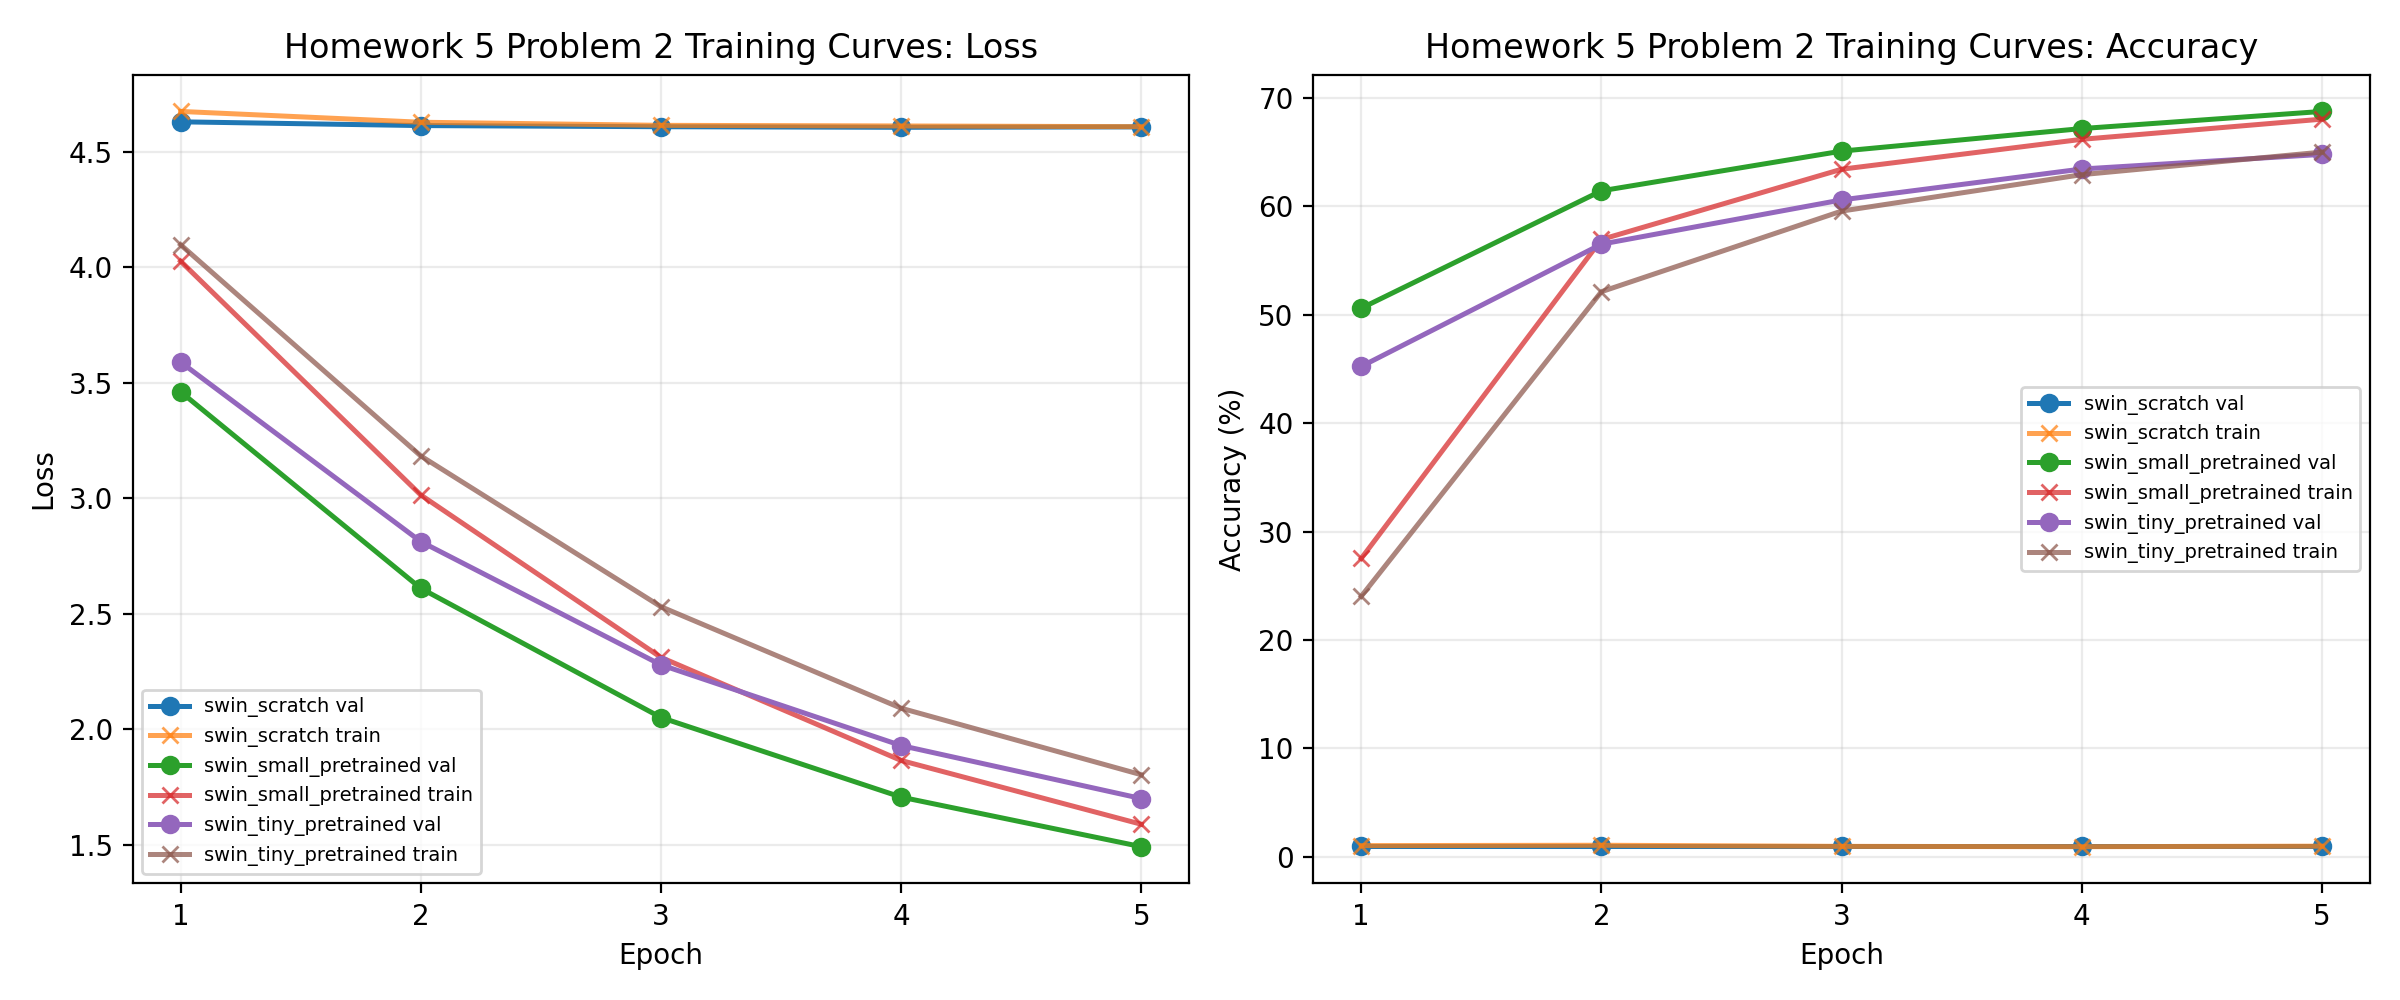

### Per-Model Accuracy Points

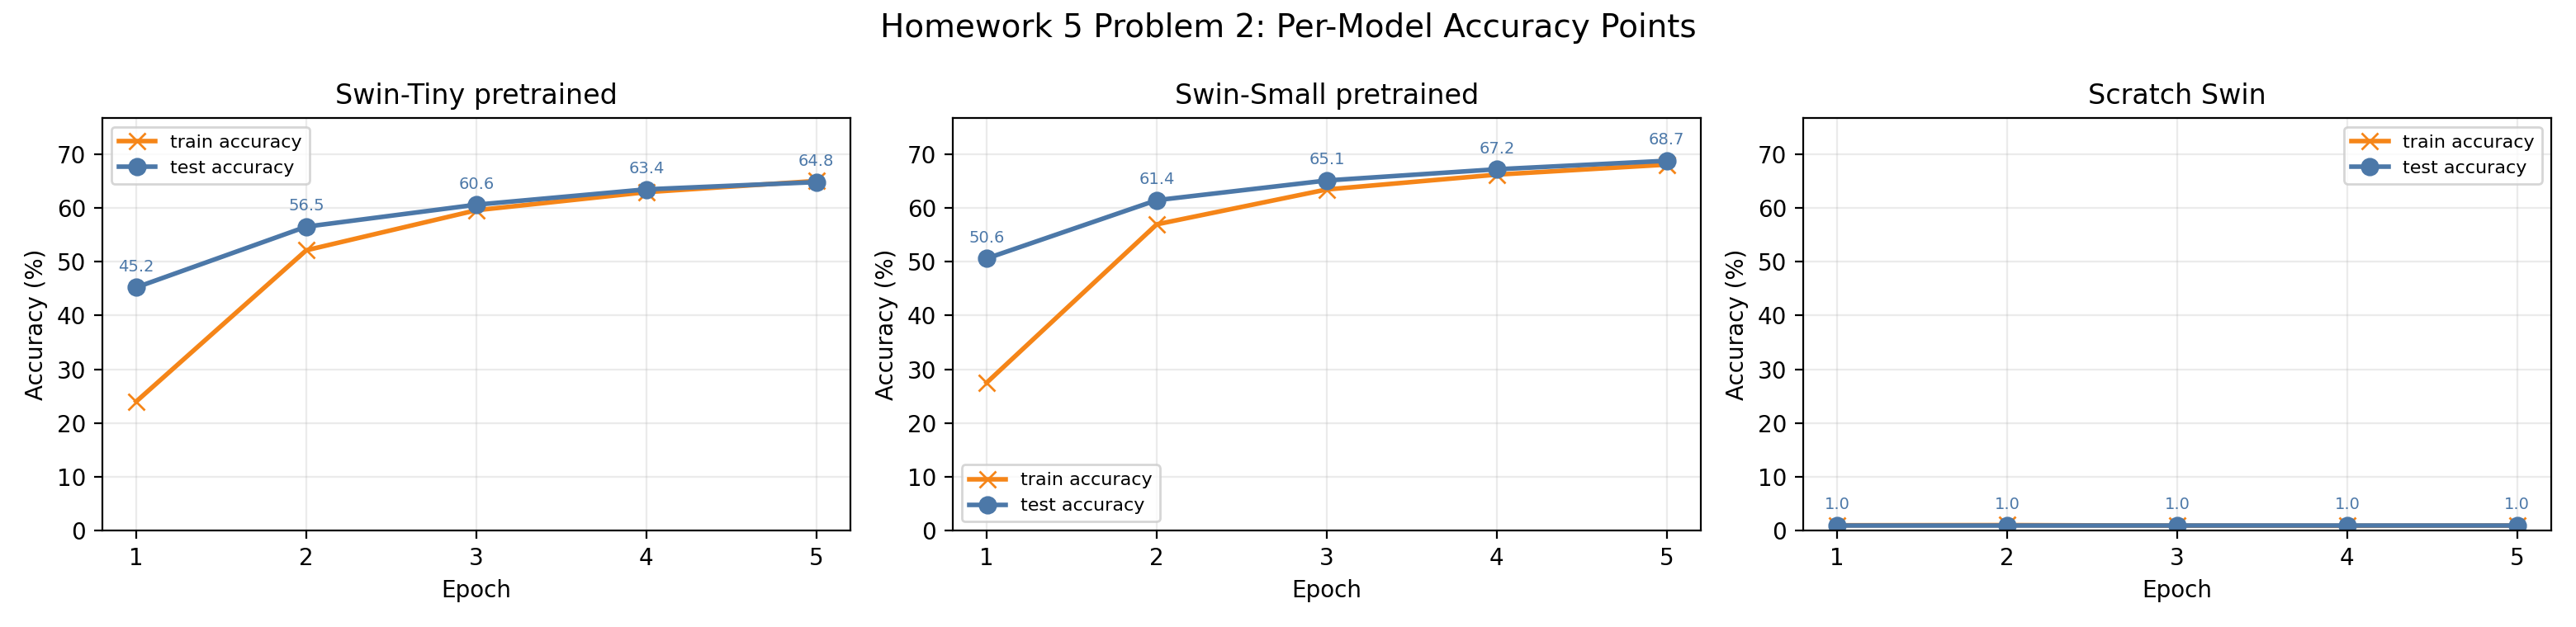

### Per-Epoch Metric Grid

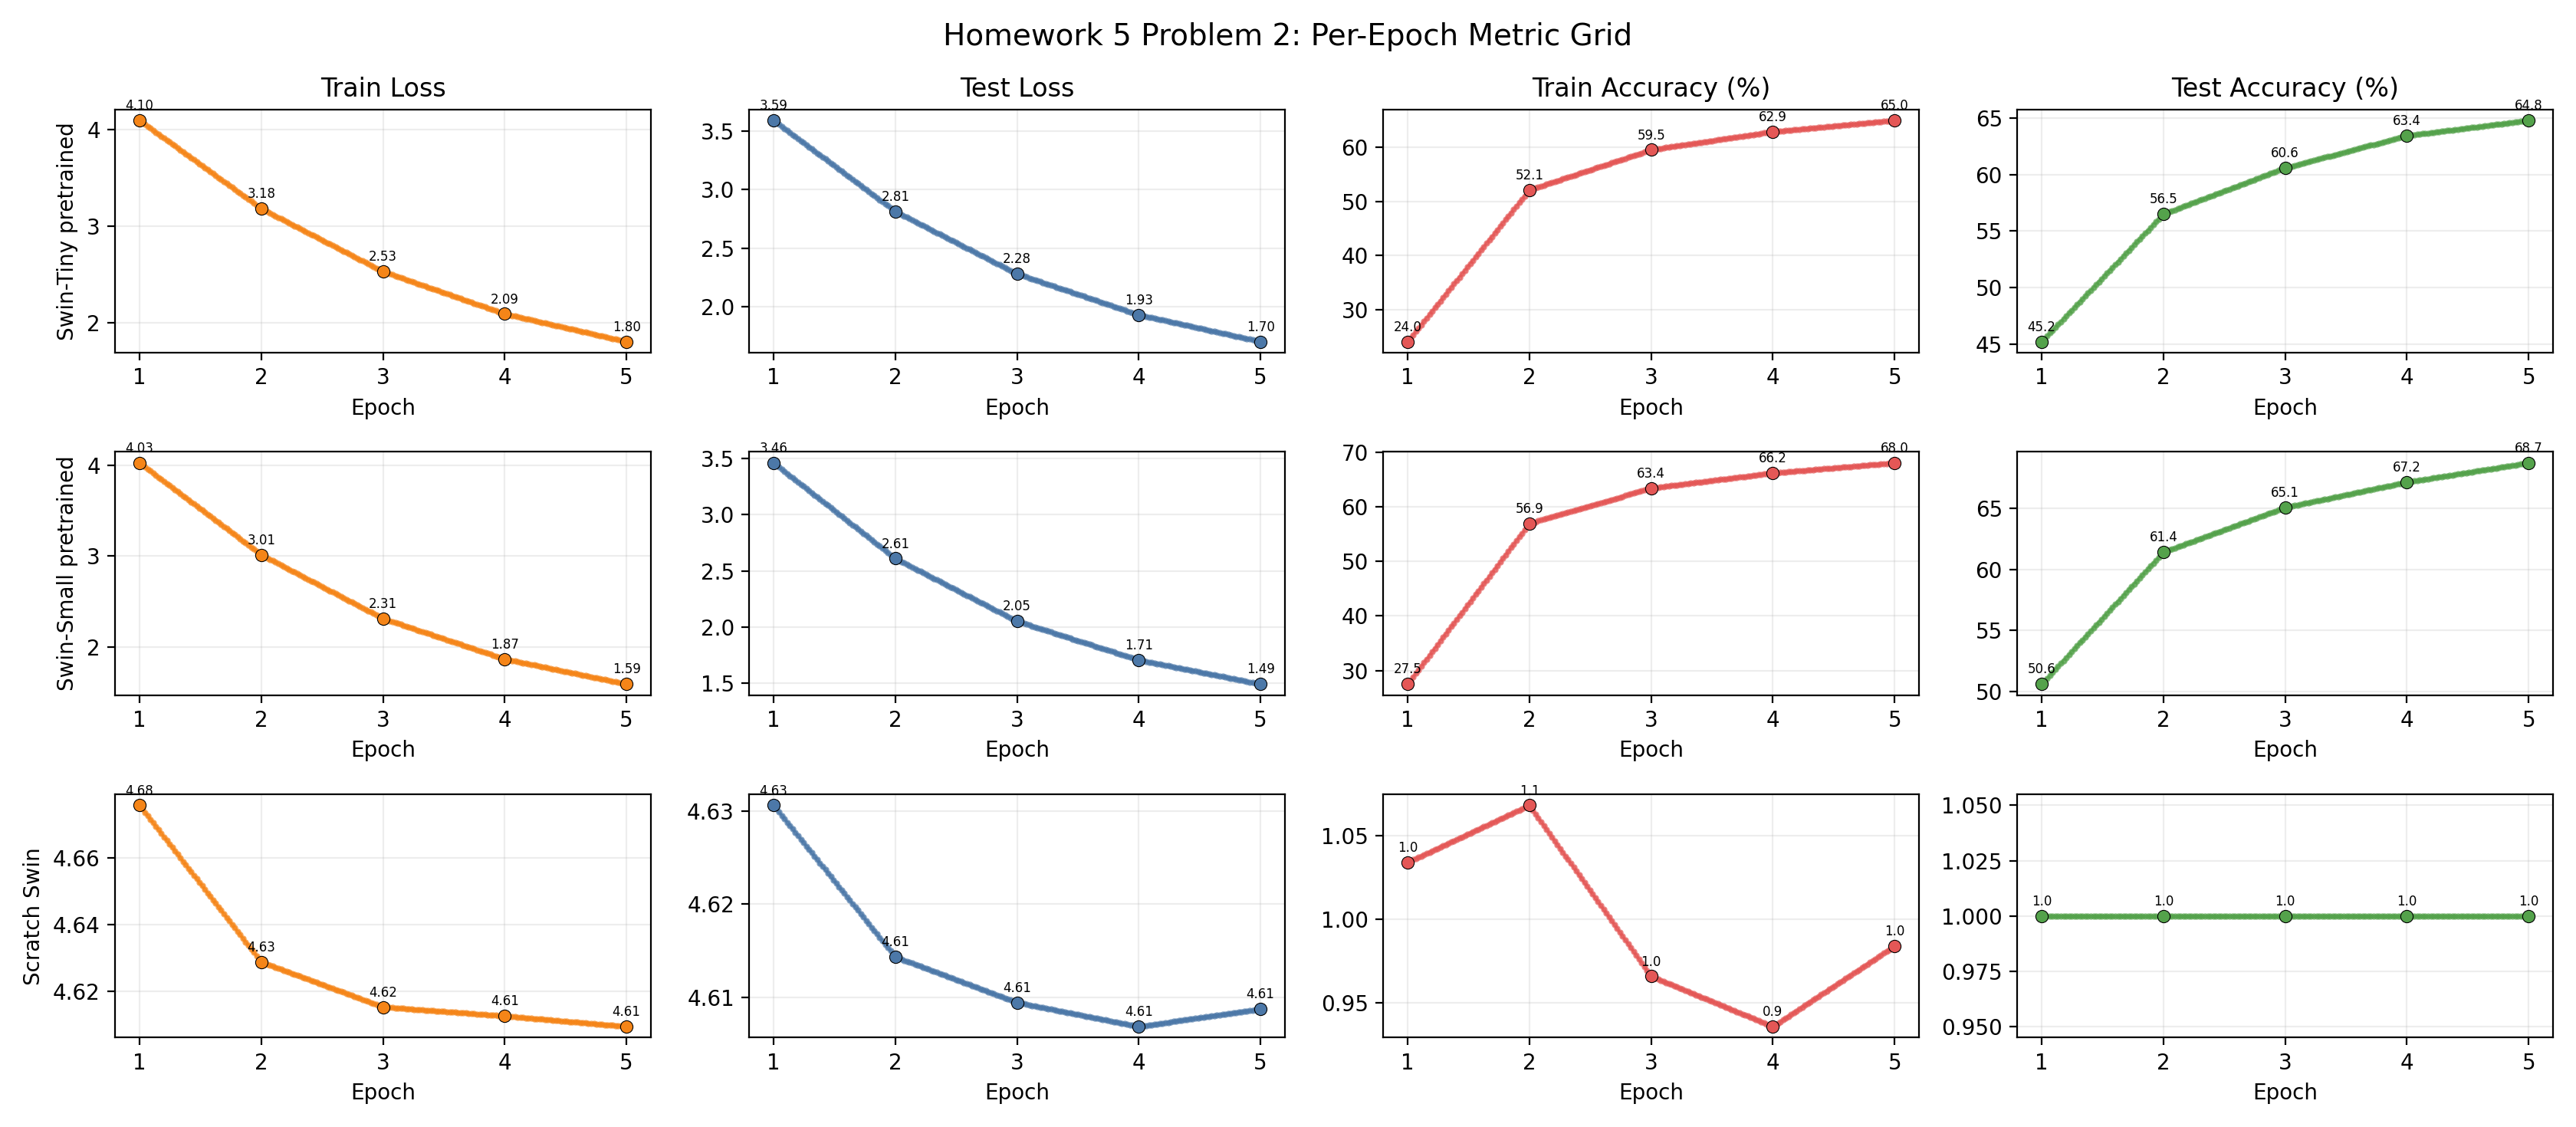

### Reference-Style Dense Trend Curves

Small dots are interpolated samples between measured epochs; the larger black-edged dots are the measured epoch results.

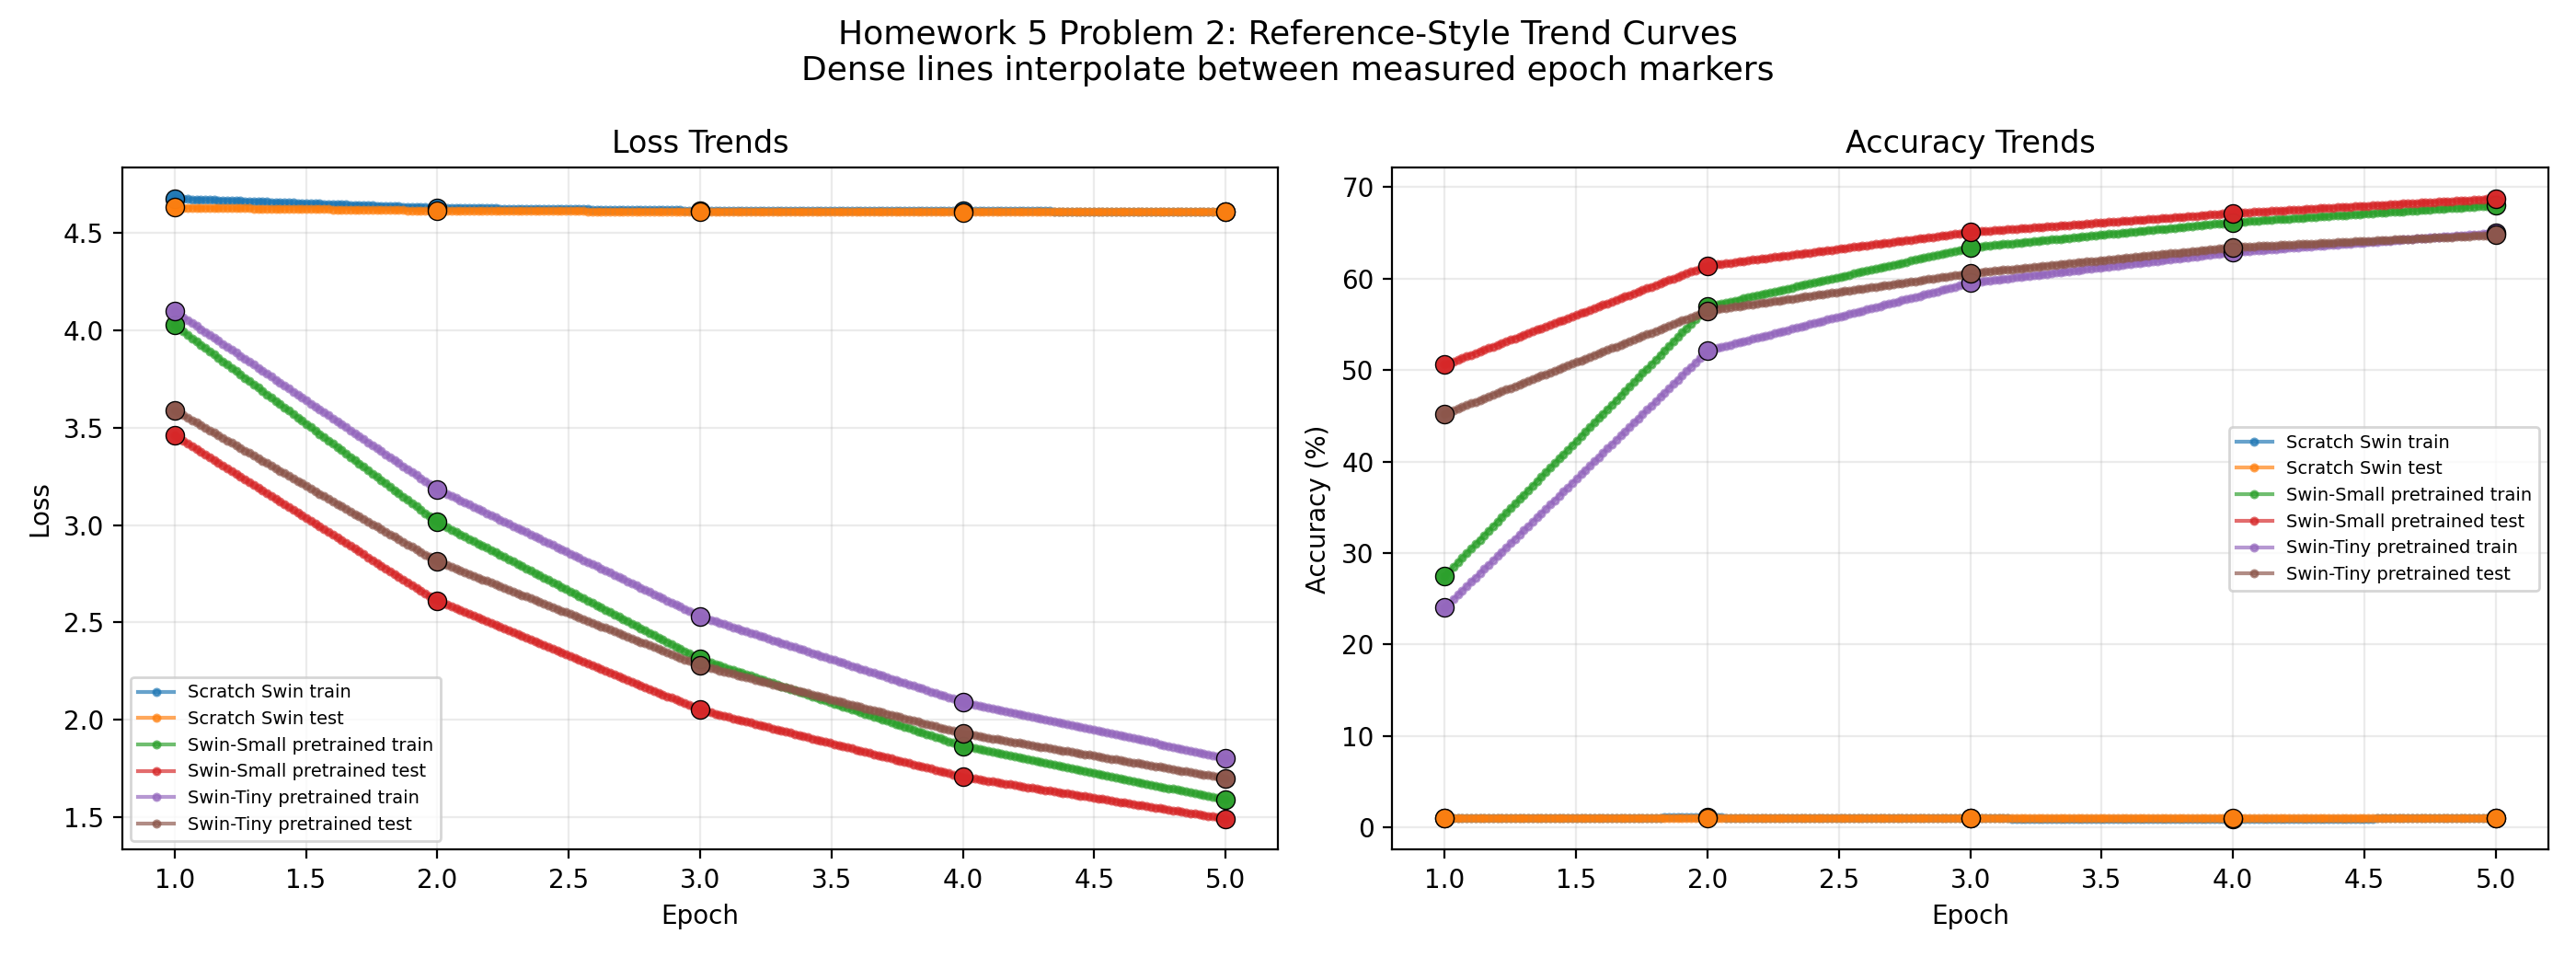

### Accuracy, Runtime, and Fine-Tuning Tradeoffs

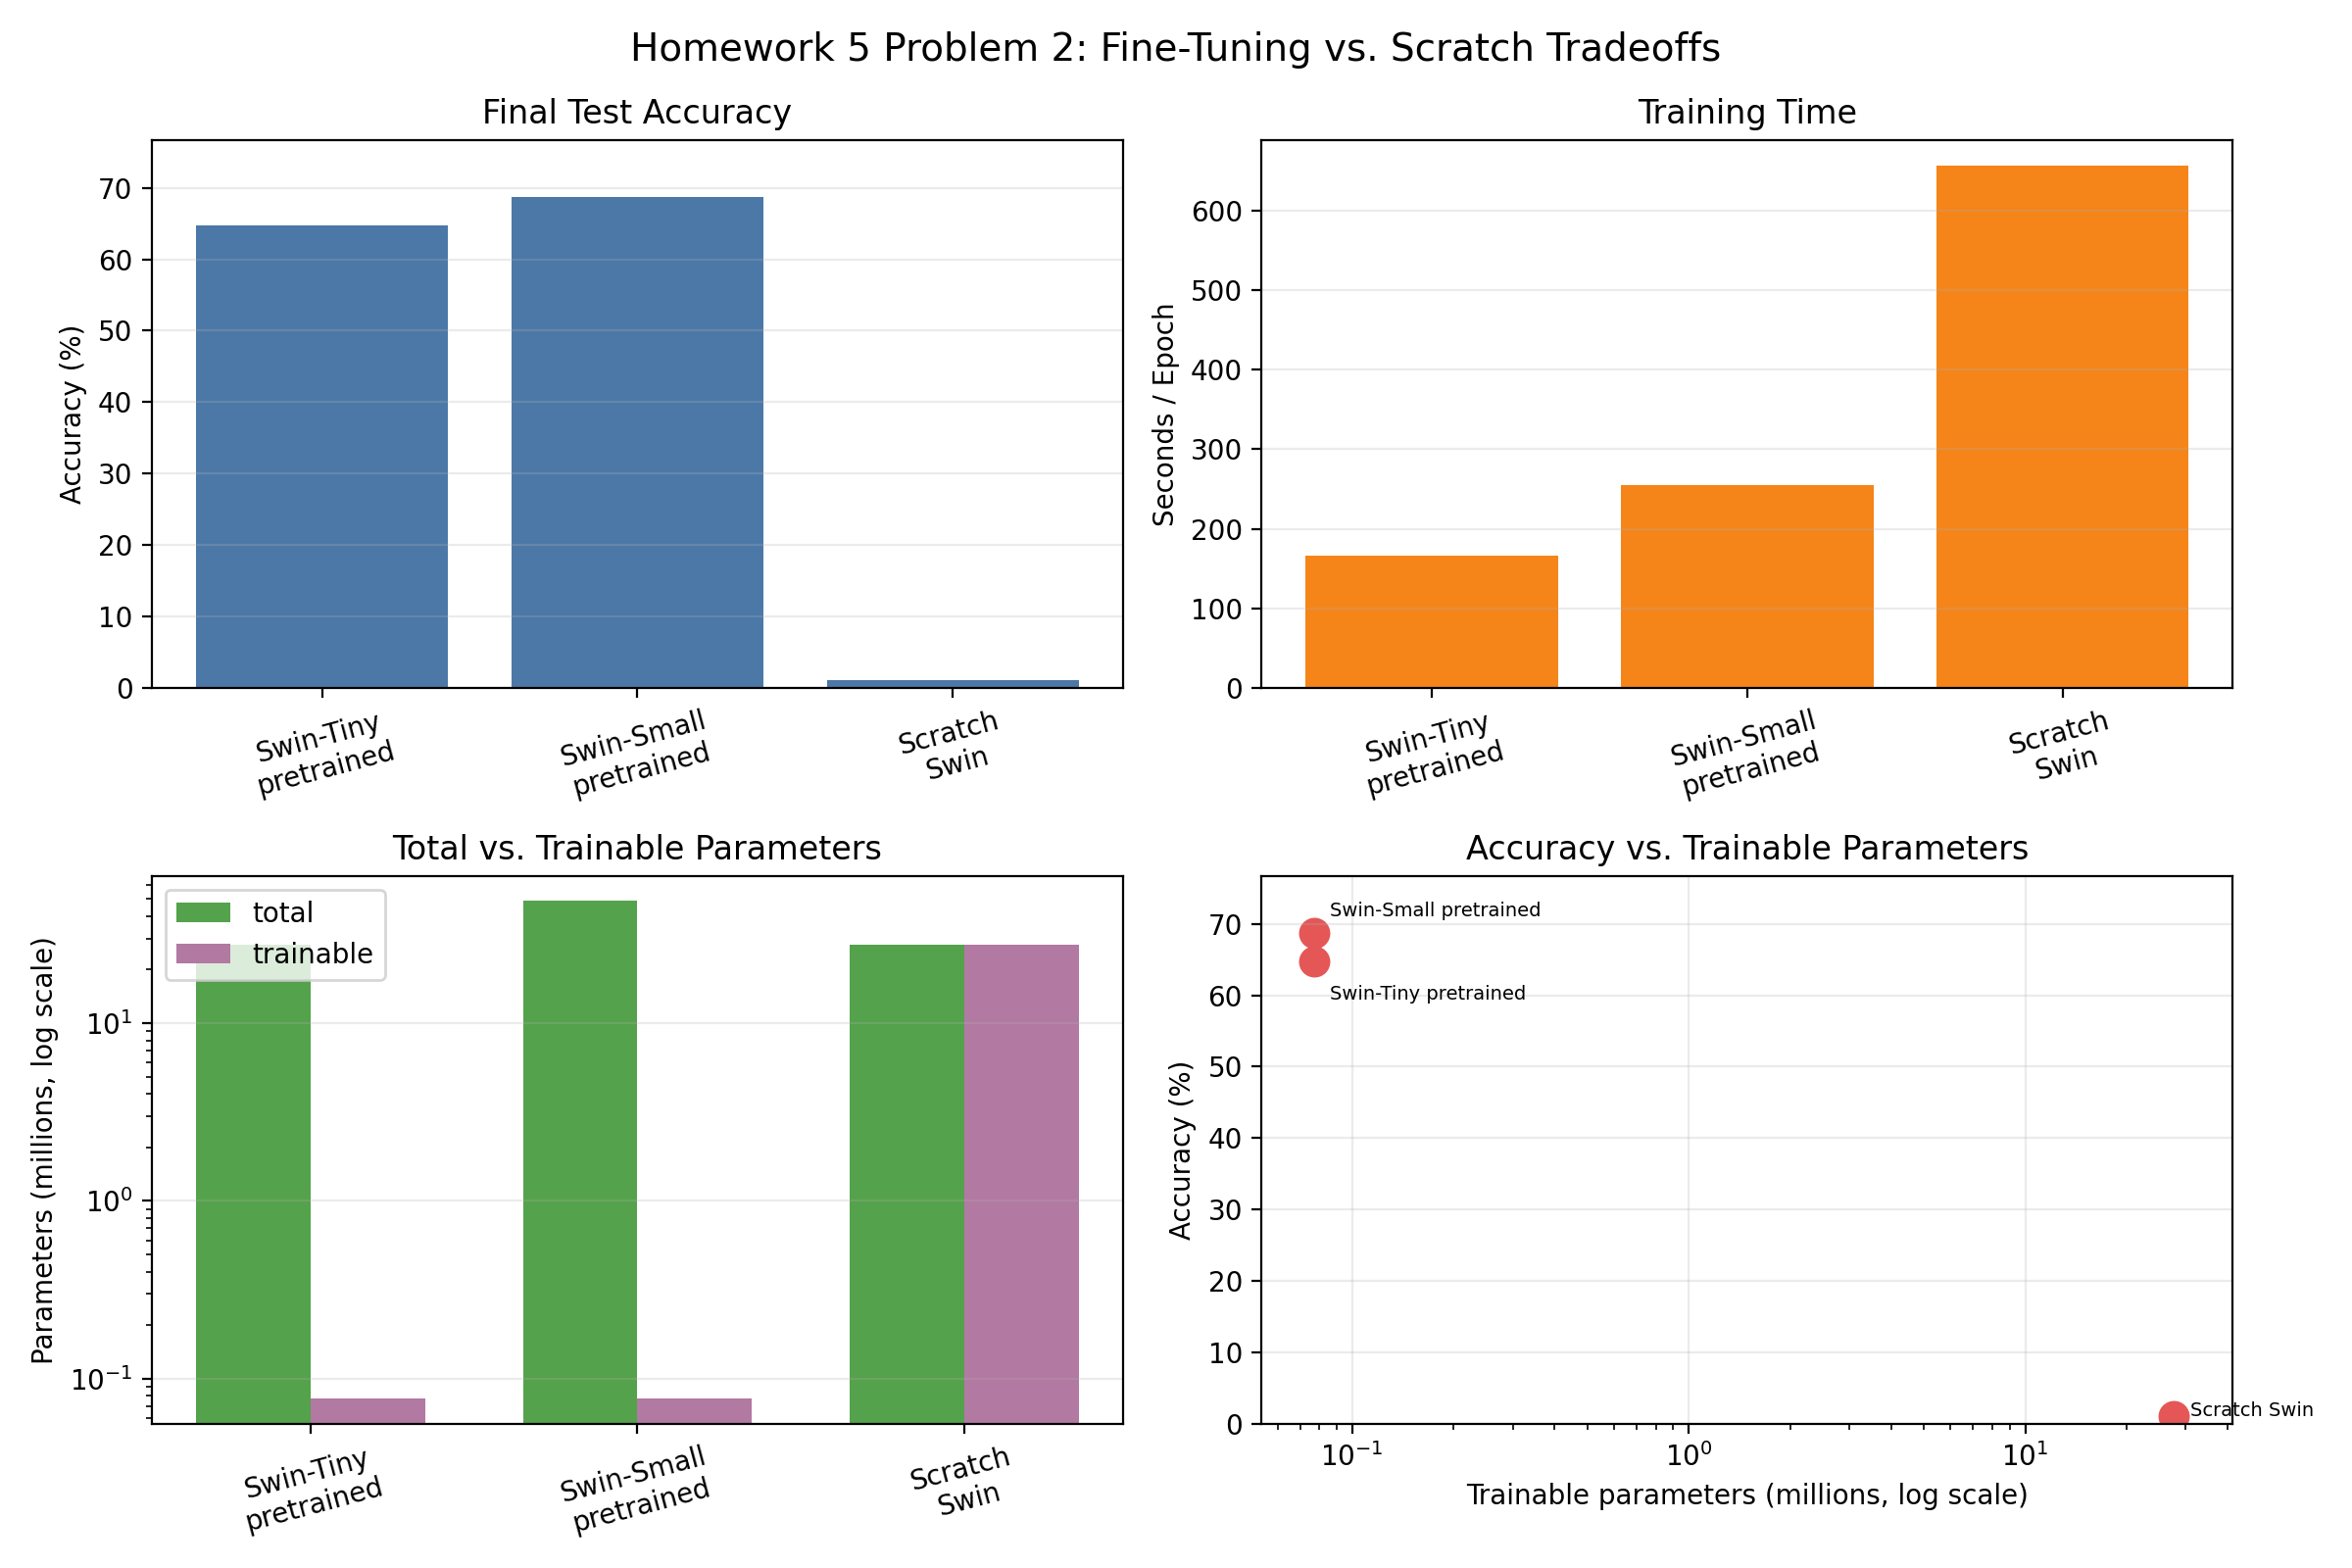

In [14]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Per-Model Accuracy Points'))
display(Image(filename=str(detail_path)))
display(Markdown('### Per-Epoch Metric Grid'))
display(Image(filename=str(metric_grid_path)))
display(Markdown('### Reference-Style Dense Trend Curves'))
display(Markdown('Small dots are interpolated samples between measured epochs; the larger black-edged dots are the measured epoch results.'))
display(Image(filename=str(trend_path)))
display(Markdown('### Accuracy, Runtime, and Fine-Tuning Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

The pretrained Swin models clearly benefit from transfer learning. Swin-Tiny reaches 64.78% test accuracy and Swin-Small reaches 68.74% after only five epochs while training just the classifier head. The frozen backbones already contain useful visual features, so the small trainable head can adapt those features to CIFAR-100 quickly.

Swin-Small performs better than Swin-Tiny, but it also costs more time per epoch and has a larger total parameter count. Because both pretrained runs freeze the backbone, they have the same trainable classifier-head parameter count, but Swin-Small still requires more forward-pass compute through its larger backbone.

The scratch Swin result stays near chance accuracy at 1.00%. Its validation loss remains close to `ln(100)`, which is what we expect when a 100-class classifier has not learned meaningful class separation. This does not mean Swin is a bad architecture; it means that training a transformer-style vision model from random initialization for only five epochs is not enough under this setup.
